In [1]:
import pandas as pd
import scanpy as sc
import sys
import numpy as np
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt
sc.set_figure_params(dpi=150, ipython_format='retina')

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

### Attach gene symbols to Ensembl IDs.

Since we only have Ensemble IDs, we need gene symbols to find mitochondrial genes.

In [3]:
from src.attach_gene_symbols import create_mapping, attach_gene_symbol

In [4]:
gtf = PROJECT_ROOT / "data" / "reference" / "Homo_sapiens.GRCh37.87.gtf.gz"
id_mapping_df = create_mapping(gtf_path = gtf)
id_mapping_df.head()

,gene_symbol
ensembl_id,
ENSG00000000003,TSPAN6
ENSG00000000005,TNMD
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000460,C1orf112


In [5]:
adata_path = PROJECT_ROOT / "data" / "interim" / "E-MTAB-8410_raw.h5ad"
adata = sc.read_h5ad(adata_path)

In [6]:
adata = attach_gene_symbol(mapping = id_mapping_df, adata = adata)

In [7]:
print(adata.var.head())

                  source_gene_id gene_symbol
ENSG00000000003  ENSG00000000003      TSPAN6
ENSG00000000005  ENSG00000000005        TNMD
ENSG00000000419  ENSG00000000419        DPM1
ENSG00000000457  ENSG00000000457       SCYL3
ENSG00000000460  ENSG00000000460    C1orf112


### Quality control

In [8]:
from src.qc_preprocess import calculate_qc_metrics, plot_qc_metrics

In [9]:
calculate_qc_metrics(adata)
adata.obs[["n_genes_by_counts","total_counts","pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
SAMEA6057388-AAAACCGAGATGGGTC,742,1017.000010,8.357915
SAMEA6057388-AAAACCGCATGAACCT,664,1048.999992,2.097235
SAMEA6057388-AAAACCGCATTACCTT,293,305.000000,1.967213
SAMEA6057388-AAAACCGGTATAGGTA,514,722.999999,5.117566
SAMEA6057388-AAAACCGGTTGCGTTA,728,1093.999992,0.000000


In [10]:
plot_qc_metrics(adata, fig_dir = PROJECT_ROOT / "figures",)

In [11]:
from src.qc_preprocess import get_sample_qc_summary

The QC plots showed that some samples had very high percentages of MT genes so a per-sample QC summary was generated to help guide next steps.

In [12]:
per_sample_qc_table = get_sample_qc_summary(adata)
print(per_sample_qc_table)

              cells  median_mt  median_genes  median_counts  frac_mt_over_20  \
biosample_id                                                                   
SAMEA6057408  40146  83.320962          57.0     285.000000         0.976585   
SAMEA6057407  47816  66.554458         132.0     365.000003         0.986929   
SAMEA6057406   3374  54.228208         356.0    1116.499996         0.851808   
SAMEA6057401  33519  43.412162         151.0     287.999999         0.933650   
SAMEA6057400  49351  34.343435         166.0     242.999996         0.800126   
SAMEA6057405   3604  22.089456         268.0     415.999996         0.541898   
SAMEA6057409    408  17.938125        3302.5   12586.999975         0.465686   
SAMEA6057411   5422  17.564271         576.0     992.499996         0.450387   
SAMEA6057410    419  15.618794        3611.0   16346.000080         0.317422   
SAMEA6057397   5041  14.361702         340.0     781.000002         0.413410   
SAMEA6057393   5965  12.723464         2

In [13]:
good_sample_ids = per_sample_qc_table.loc[per_sample_qc_table["median_mt"] < 20].index
bad_sample_ids = per_sample_qc_table.loc[per_sample_qc_table["median_mt"] >= 20].index
adata.obs.loc[
    adata.obs["biosample_id"].isin(bad_sample_ids),
    ["biosample_id", "sampling_site", "organism_part", "individual"],
].drop_duplicates()

,biosample_id,sampling_site,organism_part,individual
SAMEA6057400-AAACACGACGCTCTTC,SAMEA6057400,tumour core,colon,SC027
SAMEA6057401-AAACACGACGCTCTTC,SAMEA6057401,tumour border,colon,SC027
SAMEA6057405-AAACCTGAGACCTAGG,SAMEA6057405,normal tissue adjacent to neoplasm,sigmoid colon,SC028 (KUL28)
SAMEA6057406-AAACCTGAGCGATCCC,SAMEA6057406,tumour core,colon,SC029
SAMEA6057407-AAACCTGAGAACAACT,SAMEA6057407,tumour border,colon,SC029
SAMEA6057408-AAACCTGAGAATCTCC,SAMEA6057408,normal tissue adjacent to neoplasm,colon,SC029


Samples with poor QC stats, specifically containing cells with high percentage of mitochondrial genes, originated from different sampling sites and different parts of the colon indicating that this issue is not confined to a single sampling site category. A two-step filtering strategy was adopted to filter out poor quality cells. First, poor quality cells from "good" samples were filtered out using MAD-based QC within each sample that removes low gene and high mitochondrial gene percent cells. The remaining cells are used as reference to salvage good quality cells from the bad samples.

In [14]:
from src.qc_preprocess import mad_outlier

In [15]:
# Mark which cells belong to reference-good samples.
adata.obs["is_good_sample"] = adata.obs["biosample_id"].isin(good_sample_ids)

cells_in_good_samples = adata.obs["is_good_sample"]

# Initialize flags
adata.obs["qc_low_counts"] = False
adata.obs["qc_low_genes"] = False
adata.obs["qc_high_mt"] = False

for sample, cell_index in (
    adata.obs.loc[cells_in_good_samples]
    .groupby("biosample_id", observed=True)
    .groups
    .items()
):
    sample_obs = adata.obs.loc[cell_index]

    adata.obs.loc[cell_index, "qc_low_counts"] = mad_outlier(
        sample_obs["total_counts"],
        nmads=3,
        direction="lower",
        log1p=True)

    adata.obs.loc[cell_index, "qc_low_genes"] = mad_outlier(
        sample_obs["n_genes_by_counts"],
        nmads=3,
        direction="lower",
        log1p=True)

    adata.obs.loc[cell_index, "qc_high_mt"] = mad_outlier(
        sample_obs["pct_counts_mt"],
        nmads=3,
        direction="upper",
        log1p=False)

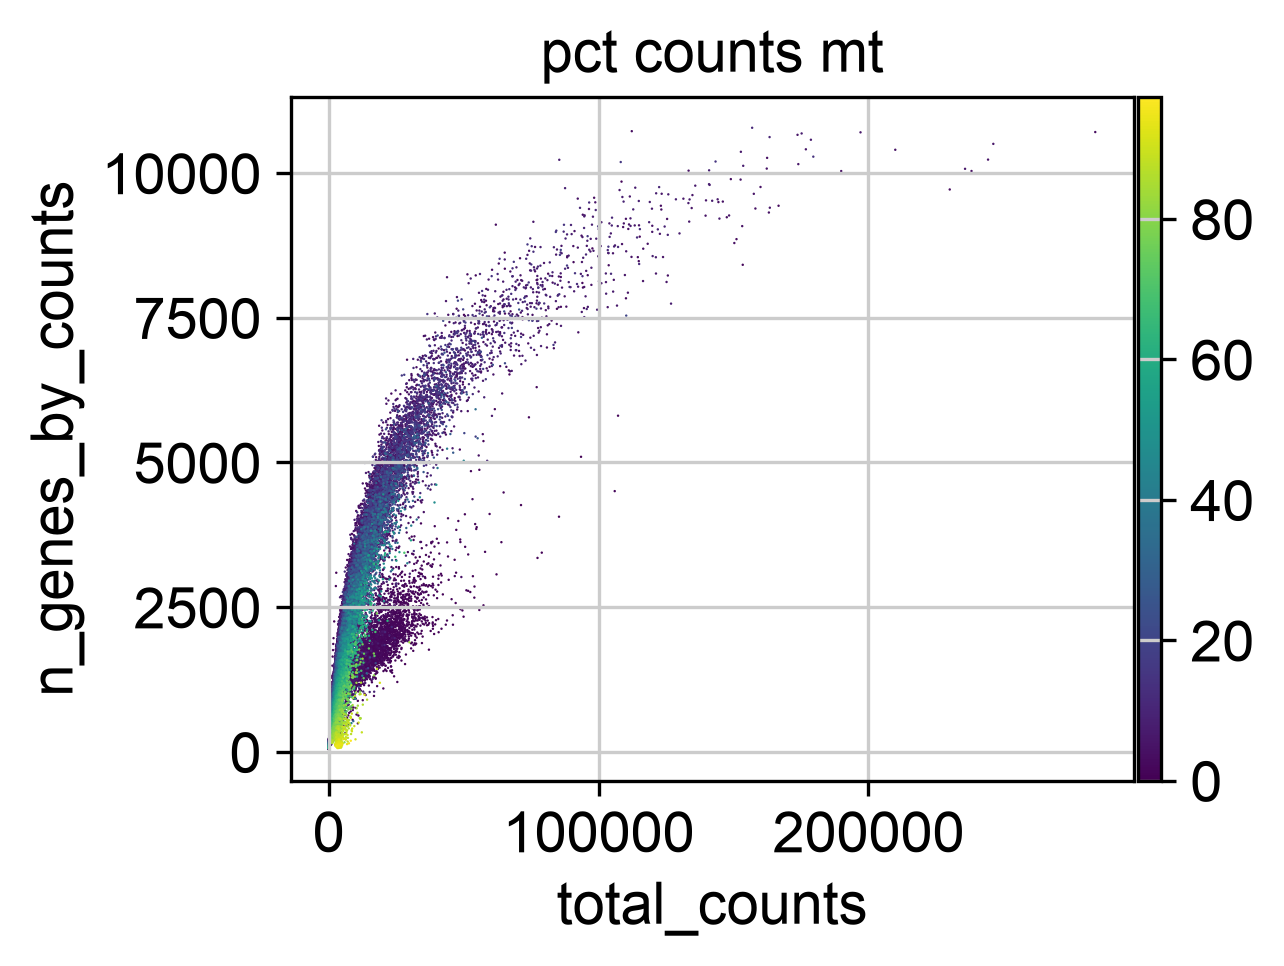

In [16]:
with plt.rc_context({"figure.figsize": (4, 3)}):
    sc.pl.scatter(
    adata[cells_in_good_samples].copy(),
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)


In [17]:
MIN_GENES = 300
MAX_MT_PCT = 20.0

adata.obs["qc_very_low_genes"] = (
    adata.obs["n_genes_by_counts"] < MIN_GENES
)

adata.obs["qc_very_high_mt"] = (
    adata.obs["pct_counts_mt"] > MAX_MT_PCT
)

adata.obs["qc_fail_good_sample"] = (
    cells_in_good_samples
    & (
        adata.obs["qc_low_counts"]
        | adata.obs["qc_low_genes"]
        | adata.obs["qc_high_mt"]
        | adata.obs["qc_very_low_genes"]
        | adata.obs["qc_very_high_mt"]
    )
)

retention_in_good_samples = (
    adata.obs.loc[cells_in_good_samples]
    .assign(keep=~adata.obs.loc[cells_in_good_samples, "qc_fail_good_sample"])
    .groupby("biosample_id", observed=True)
    .agg(
        cells_before=("keep", "size"),
        cells_kept=("keep", "sum"),
        fraction_kept=("keep", "mean"),
        median_mt=("pct_counts_mt", "median"),
        max_mt_kept=(
            "pct_counts_mt",
            lambda values: values[
                ~adata.obs.loc[values.index, "qc_fail_good_sample"]
            ].max()
        ),
        median_genes=("n_genes_by_counts", "median"),
        min_genes_kept=(
            "n_genes_by_counts",
            lambda values: values[
                ~adata.obs.loc[values.index, "qc_fail_good_sample"]
            ].min()
        ),
        median_counts=("total_counts", "median"),
    )
    .sort_values("fraction_kept")
)

display(retention_in_good_samples)

,cells_before,cells_kept,fraction_kept,median_mt,max_mt_kept,median_genes,min_genes_kept,median_counts
biosample_id,,,,,,,,
SAMEA6057403,2066,649,0.314134,12.503909,19.705341,194.0,300,279.499998
SAMEA6057393,5965,2169,0.363621,12.723464,19.993570,279.0,300,465.999998
SAMEA6057396,4662,1709,0.366581,11.544809,20.000000,268.5,300,508.999999
SAMEA6057413,4129,1597,0.386776,7.981053,19.985577,256.0,300,315.999999
SAMEA6057397,5041,1979,0.392581,14.361702,19.983390,340.0,300,781.000002
SAMEA6057390,6087,2408,0.395597,10.179641,19.971057,418.0,300,961.000001
SAMEA6057411,5422,2380,0.438952,17.564271,19.999165,576.0,303,992.499996
SAMEA6057409,408,182,0.446078,17.938125,19.882203,3302.5,1520,12586.999975
SAMEA6057394,5384,2465,0.457838,5.846055,16.645379,642.0,301,1284.499994


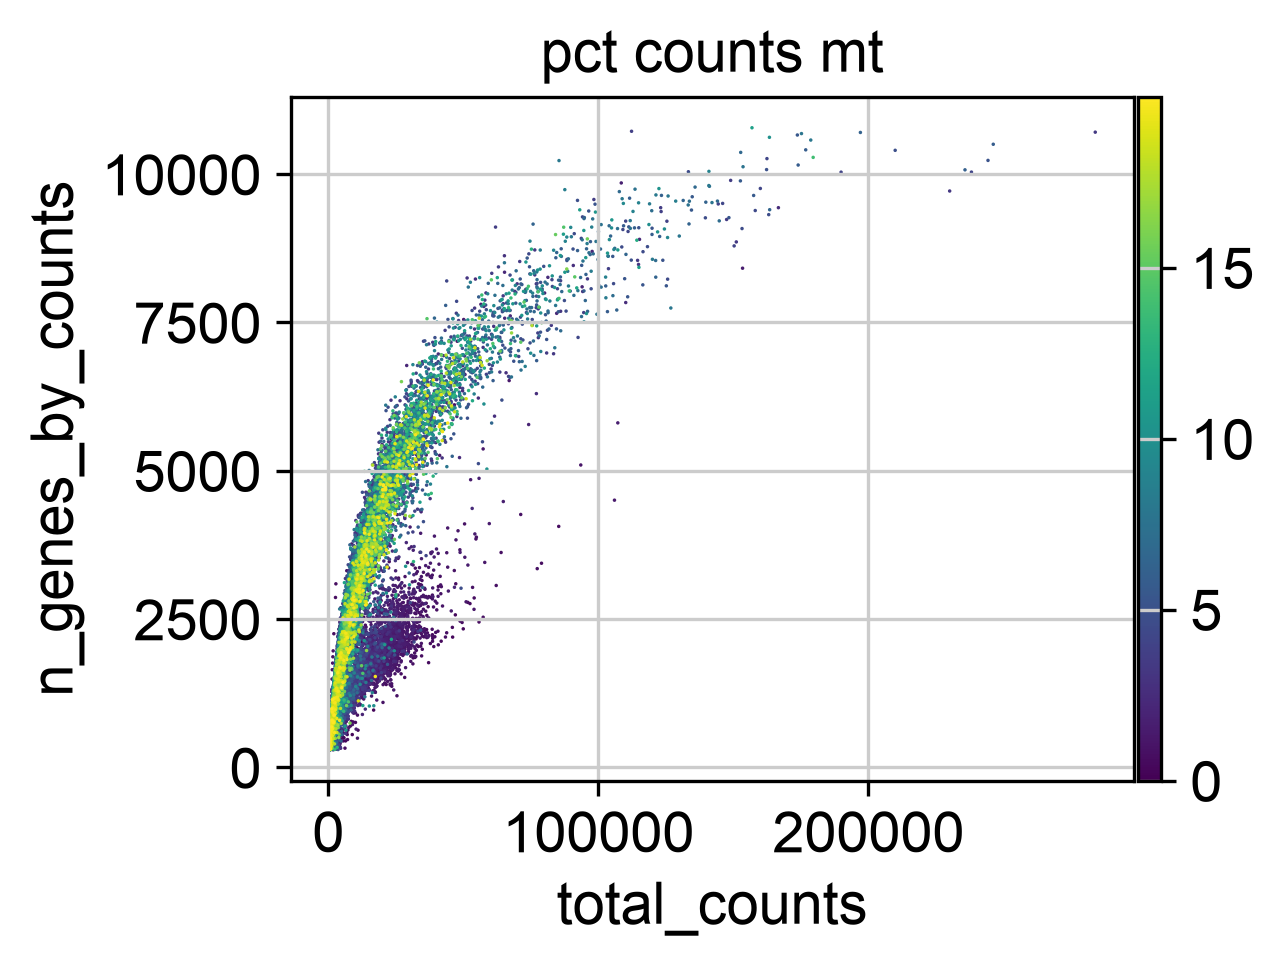

In [18]:
cells_kept_from_good_samples = (
    adata.obs["is_good_sample"]
    & ~adata.obs["qc_fail_good_sample"]
)

with plt.rc_context({"figure.figsize": (4, 3)}):
    sc.pl.scatter(
    adata[cells_kept_from_good_samples].copy(),
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)


In [19]:
# Create references from good cells from good samples
reference_log_genes = np.log1p(adata.obs.loc[
    cells_kept_from_good_samples,
    "n_genes_by_counts"])

reference_gene_median = reference_log_genes.median()
reference_gene_mad = np.median(abs(reference_log_genes - reference_gene_median))
min_genes_reference = np.expm1(reference_gene_median - 2 * reference_gene_mad)

reference_mt = adata.obs.loc[
    cells_kept_from_good_samples,
    "pct_counts_mt"]
reference_mt_median = reference_mt.median()
reference_mt_mad = np.median(np.abs(reference_mt - reference_mt_median))
max_mt_reference = reference_mt_median + 3 * reference_mt_mad

print(f"Median pctMT in reference: {reference_mt_median}")
print(f"Median genes in reference: {np.expm1(reference_gene_median)}")
print(f"Minimum detected genes: {min_genes_reference:.0f}")
print(f"Maximum MT percentage: {max_mt_reference:1f}%")

Median pctMT in reference: 4.660359312584884
Median genes in reference: 1353.0000000000002
Minimum detected genes: 453
Maximum MT percentage: 10.748281%


Next, cells from bad samples with good QC stats are retained. The question is: “Do we have enough evidence that this individual barcode represents an intact, informative cell despite its library being broadly degraded?”

In [20]:
MIN_GENES = max(min_genes_reference, 300)
# https://pmc.ncbi.nlm.nih.gov/articles/PMC9279158/
MAX_MT_PCT = min(max_mt_reference, 20.0)

bad_cell_mask = ~adata.obs["is_good_sample"]

adata.obs["qc_keep_cell_from_bad_sample"] = (
    bad_cell_mask
    & (adata.obs["n_genes_by_counts"] >= MIN_GENES)
    & (adata.obs["pct_counts_mt"] <= MAX_MT_PCT)
)

In [21]:
bad_sample_salvage = (
    adata.obs.loc[bad_cell_mask]
    .assign(keep=lambda df: df["qc_keep_cell_from_bad_sample"])
    .groupby("biosample_id", observed=True)
    .agg(
        cells_before=("keep", "size"),
        cells_salvaged=("keep", "sum"),
        fraction_salvaged=("keep", "mean"),
        median_mt=("pct_counts_mt", "median"),
        max_mt_kept=(
            "pct_counts_mt",
            lambda values: values[
                adata.obs.loc[values.index, "qc_keep_cell_from_bad_sample"]
            ].max()
        ),
        median_genes=("n_genes_by_counts", "median"),
        median_counts=("total_counts", "median"),
    )
    .sort_values("fraction_salvaged")
)

display(bad_sample_salvage)

,cells_before,cells_salvaged,fraction_salvaged,median_mt,max_mt_kept,median_genes,median_counts
biosample_id,,,,,,,
SAMEA6057407,47816,148,0.003095,66.554458,10.741276,132.0,365.000003
SAMEA6057408,40146,445,0.011085,83.320962,10.646261,57.0,285.000000
SAMEA6057401,33519,929,0.027716,43.412162,10.743269,151.0,287.999999
SAMEA6057400,49351,1900,0.038500,34.343435,10.733453,166.0,242.999996
SAMEA6057406,3374,180,0.053349,54.228208,10.736407,356.0,1116.499996
SAMEA6057405,3604,737,0.204495,22.089456,10.738557,268.0,415.999996


In [22]:
# Final: filter cells
final_keep_mask = (
    cells_kept_from_good_samples | adata.obs["qc_keep_cell_from_bad_sample"]
)
n_cells_before = adata.n_obs
n_cells_kept = final_keep_mask.sum()
n_cells_removed = (~final_keep_mask).sum()
fraction_kept = final_keep_mask.mean()

print(f"Cells before QC:  {n_cells_before:,}")
print(f"Cells kept:       {n_cells_kept:,}")
print(f"Cells removed:    {n_cells_removed:,}")
print(f"Fraction kept:    {fraction_kept:.1%}")

Cells before QC:  267,298
Cells kept:       47,103
Cells removed:    220,195
Fraction kept:    17.6%


In [23]:
retention_by_path = pd.DataFrame(
    {
        "cells": [
            adata.n_obs,
            (
                adata.obs["is_good_sample"]
                & ~adata.obs["qc_fail_good_sample"]
            ).sum(),
            adata.obs["qc_keep_cell_from_bad_sample"].sum(),
            final_keep_mask.sum(),
        ],
    },
    index=[
        "input_cells",
        "kept_from_good_samples",
        "salvaged_from_bad_samples",
        "final_kept",
    ],
)

retention_by_path["fraction_of_input"] = (
    retention_by_path["cells"] / adata.n_obs
)

display(retention_by_path)

,cells,fraction_of_input
input_cells,267298,1.000000
kept_from_good_samples,42764,0.159986
salvaged_from_bad_samples,4339,0.016233
final_kept,47103,0.176219


In [24]:
# Created post-QC adata object
adata_qc = adata[final_keep_mask].copy()

### Doublet removal
The counts are not all integers so Scrublet cannot be used.

In [25]:
from src.ingest_data import write_h5ad

In [26]:
write_h5ad(
    adata_qc,
    output_path = PROJECT_ROOT / "data" / "interim" / "E-MTAB-8410_qc.h5ad"
)